In [1]:
import numpy as np
from sim_library.data_io import load_p_dists
from sim_library.constants import hbar, k_eff, m, kb, pi
from sim_library.plotting import plot_hist, fit_gaussian
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
path = Path("data/algorithmic cooling/2026-03-30_algcooling_f3_8cycles_15muK_10000atoms_1e+09Hz.h5")
loaded_dict = load_p_dists(file_path=path)
moms_list = loaded_dict["p_list"]
fracs_list = loaded_dict["weights_list"]
n_atoms = loaded_dict["n_atoms"]
basis = loaded_dict["basis"]
init_temp = loaded_dict["init_temp"]
cycles = loaded_dict["cycles"]
moms_list = [mom / (hbar * k_eff) for mom in moms_list]


c:\Users\tr2g20\OneDrive - University of Southampton\Documents\Research\Code\Simulation\sim_library\plotting.py:295: RuntimeWarning: invalid value encountered in sqrt
  return (amp*hbar*k_eff/(np.sqrt(2*pi*m*kb*T)))*np.exp(-((hbar*k_eff)*(p-mu))**2/(2*kb*T*m))
c:\Users\tr2g20\OneDrive - University of Southampton\Documents\Research\Code\Simulation\sim_library\plotting.py:295: RuntimeWarning: overflow encountered in exp
  return (amp*hbar*k_eff/(np.sqrt(2*pi*m*kb*T)))*np.exp(-((hbar*k_eff)*(p-mu))**2/(2*kb*T*m))


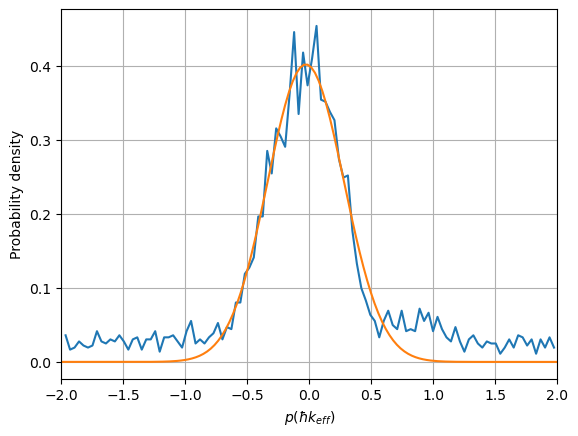

(0.3097338145282276,
 1.391495575087048e-07,
 -0.028905763265869112,
 array([[ 5.61472399e-05,  3.36318323e-11,  9.34075985e-16],
        [ 3.36318323e-11,  6.04357470e-17, -1.44690343e-19],
        [ 9.34075985e-16, -1.44690343e-19,  7.37578110e-05]]))

In [3]:
fit_gaussian(moms=moms_list[-1], fracs=fracs_list[-1], lowlim=-2, highlim=2, nbins=1000, plot=True)

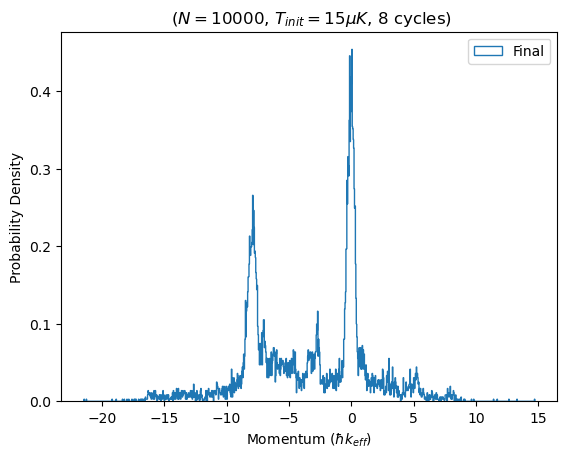

In [162]:
title = ''

fig, ax = plt.subplots()

counts, bins, _ = ax.hist(x= moms_list[-1], weights= fracs_list[-1], bins = 1000, histtype='step', density=True, label= 'Final')
ax.set_title(rf"{title} ($N={n_atoms}$, $T_{{init}}={init_temp*1e6:.3g}\mu K$, {cycles} cycles)")
ax.set_ylabel('Probability Density')
ax.set_xlabel(r"Momentum ($\hbar k_{eff}$)")
ax.legend()
# ax.set_xlim(basis[0], basis[-1])
# ax.set_ylim(0,0.6)

bins  = bins[0:-1]

[ 3.09734090e-01  1.39150053e-07 -2.89058092e-02]


C:\Users\tr2g20\AppData\Local\Temp\ipykernel_15332\1299257581.py:2: RuntimeWarning: invalid value encountered in sqrt
  return (amp*hbar*k_eff/(np.sqrt(2*pi*m*kb*T)))*np.exp(-((hbar*k_eff)*(p-mu))**2/(2*kb*T*m))
C:\Users\tr2g20\AppData\Local\Temp\ipykernel_15332\1299257581.py:2: RuntimeWarning: overflow encountered in exp
  return (amp*hbar*k_eff/(np.sqrt(2*pi*m*kb*T)))*np.exp(-((hbar*k_eff)*(p-mu))**2/(2*kb*T*m))


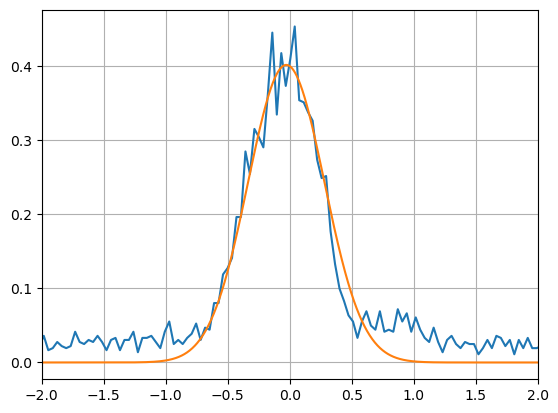

In [163]:
lowlim = -2
highlim = 2

new_bins = bins[(bins >= lowlim) & (bins <= highlim)]
bindiff = bins[1]-bins[0]
new_bins += bindiff/2
new_counts = counts[(bins >= lowlim) & (bins <= highlim)]

fitted_vals, _ = curve_fit(gaussian, new_bins, new_counts)
print(fitted_vals)


peas = np.linspace(-15,15,10000)
peasss = gaussian(peas, fitted_vals[0], fitted_vals[1], fitted_vals[2])


# print(fitted_vals)

plt.plot(bins, counts)
plt.plot(peas, peasss)
# # plt.xlim(basis[0], basis[-1])
plt.grid()
plt.xlim(lowlim,highlim)
plt.show()

In [132]:
def gaussian(p, amp, T, mu):
    return (amp*hbar*k_eff/(np.sqrt(2*pi*m*kb*T)))*np.exp(-((hbar*k_eff)*(p-mu))**2/(2*kb*T*m))